# Computer Exercise 5.2 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 5.2 Trapezoid Rule — *Euler–Maclaurin: 주기 부드러움의 기적, 특이점의 처벌*
> **풀이 일자**: Day 18
> **언어**: Python 3 (NumPy / Matplotlib / Pandas / SciPy)


## 1. 문제 (원문)

> **3.** Apply the composite trapezoid rule to three integrands of decreasing regularity
> over $[0, 1]$:
> $$
> (a)\;\int_0^1 e^{\cos(2\pi x)}\,dx \quad (\text{smooth and 1-periodic}), \qquad
> (b)\;\int_0^1 \sqrt{x}\,dx = \frac{2}{3}, \qquad
> (c)\;\int_0^1 \sqrt{x(1-x)}\,dx = \frac{\pi}{8}.
> $$
> For each, tabulate the trapezoid error against $n = 2, 4, \ldots, 4096$.
> Predict the observed convergence orders from the **Euler–Maclaurin** formula, and
> verify them by linear regression of $\log|\text{error}|$ against $\log n$.

### 한국어 풀이용 정리
- (a) **부드럽고 1-주기**인 함수 → 사다리꼴 오차가 *모든 $h^{2k}$ 항이 소거* 되어 $n$ 에 대해
  **지수적** (super-algebraic) 으로 떨어진다. 자릿수가 폭발적으로 쌓인다.
- (b) **끝점 0 에서 $\sqrt x$ 의 미분이 발산** → 오차가 $\mathcal O(n^{-3/2})$ — Euler–Maclaurin 의 *수정항* 이 leading.
- (c) **양 끝점에서 미분 특이점** → 오차가 같은 차수, 상수만 두 배 정도.

세 케이스로 *부드러움 → 차수* 의 사슬을 정량화한다.


## 2. 수학적 배경

### 2.1 Euler–Maclaurin 공식

$f \in C^{2m+2}[a,b]$ 이면

$$
T_n(f) - \int_a^b f\,dx \;=\; \sum_{k=1}^{m}\frac{B_{2k}}{(2k)!}\,h^{2k}\bigl[f^{(2k-1)}(b) - f^{(2k-1)}(a)\bigr] \;+\; R_m,
$$

여기서 $B_{2k}$ 는 Bernoulli 수, $R_m = \mathcal O(h^{2m+2})$.

### 2.2 주기 함수의 기적
$f$ 가 $[a,b]$ 에서 **충분히 매끄럽고 주기적** 이면 $f^{(k)}(a) = f^{(k)}(b)$ 가 모든 $k$ 에 대해 성립.
$\Rightarrow$ Euler–Maclaurin 의 **모든** 끝점 보정항이 사라진다.
$\Rightarrow$ 오차는 $\mathcal O(h^{2m+2})$ 의 *어떤 $m$ 에서도 성립* — 즉 *대수적이 아니라 지수적* 으로 감쇠
($f$ 가 해석적이면 $|T_n - I| \sim e^{-c n}$).

### 2.3 끝점 특이점의 처벌
$f(x) = x^{\alpha}$ ($\alpha > -1$, 정수 아님) 같은 끝점 특이점에 대해서는

$$
T_n(f) - \int_0^1 f\,dx \;\sim\; \frac{\zeta(-\alpha)}{n^{\alpha+1}},
$$

즉 *부드러움이 $\alpha + 1$ 차수만 살아남는다.*

본 문제에서:
* $f = \sqrt x$ ($\alpha = 1/2$) → 오차 $\sim n^{-3/2}$.
* $f = \sqrt{x(1-x)}$ → 양 끝에서 같은 $\alpha = 1/2$ → 오차 $\sim n^{-3/2}$, 상수만 두 배.

### 2.4 한 줄 정리

$$
\boxed{\,
\text{T 오차 차수} =
\begin{cases}
\text{지수적},     & f \in C^\infty \text{ and periodic} \\
\mathcal O(h^{2}), & f \in C^2 \text{ on } [a,b] \\
\mathcal O(h^{\alpha+1}), & f \sim x^\alpha \text{ near an endpoint}.
\end{cases}\,}
$$


## 3. 풀이 흐름

1. 세 피적분 함수와 참값을 정의.
2. $n \in \{2, 4, \ldots, 4096\}$ 에 대해 trapezoid 오차를 계산.
3. 결과를 표로 정리 — 세 함수, 각 $n$ 의 오차.
4. log–log 회귀로 차수 측정. (a) 의 작은 $n$ 만 의미 있음 (이후 round-off 영역).
5. semilogy 한 그래프에 (a), (b), (c) 의 오차를 겹쳐 — (a) 의 *직선 하강* 이 지수 수렴을 명백히 보인다.
6. loglog 그래프로 (b), (c) 의 *기울기 $-3/2$* 확인.
7. 결과 해석 — Euler–Maclaurin 의 *부드러움이 차수를 결정한다* 는 메시지.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import iv  # 수정 베셀 -- (a) 의 참값 검증

pd.set_option("display.float_format", lambda v: f"{v:.6e}")

def trapezoid(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    return h * (0.5 * (y[0] + y[-1]) + y[1:-1].sum())

# 세 함수
def f_periodic(x):  return np.exp(np.cos(2 * np.pi * x))
def f_sqrt(x):       return np.sqrt(x)
def f_arch(x):       return np.sqrt(x * (1.0 - x))

# 참값
I_periodic = float(iv(0, 1.0))   # integral of exp(cos 2 pi x) on [0,1] = I_0(1)
I_sqrt = 2.0 / 3.0
I_arch = np.pi / 8.0

print(f"(a) integral exp(cos 2pi x) dx on [0,1] = I_0(1) = {I_periodic:.15f}")
print(f"(b) integral sqrt(x) dx on [0,1]        = 2/3    = {I_sqrt:.15f}")
print(f"(c) integral sqrt(x(1-x)) dx on [0,1]    = pi/8   = {I_arch:.15f}")


(a) integral exp(cos 2pi x) dx on [0,1] = I_0(1) = 1.266065877752008
(b) integral sqrt(x) dx on [0,1]        = 2/3    = 0.666666666666667
(c) integral sqrt(x(1-x)) dx on [0,1]    = pi/8   = 0.392699081698724


In [2]:
ks = np.arange(1, 13)        # n = 2, 4, ..., 4096
ns = 2 ** ks

rows = []
for n in ns:
    Ta = trapezoid(f_periodic, 0.0, 1.0, n)
    Tb = trapezoid(f_sqrt,     0.0, 1.0, n)
    Tc = trapezoid(f_arch,     0.0, 1.0, n)
    rows.append({
        "n": int(n),
        "|err (a) periodic|":     abs(Ta - I_periodic),
        "|err (b) sqrt(x)|":      abs(Tb - I_sqrt),
        "|err (c) sqrt(x(1-x))|": abs(Tc - I_arch),
    })

df = pd.DataFrame(rows)
df


,n,|err (a) periodic|,|err (b) sqrt(x)|,|err (c) sqrt(x(1-x))|
0,2,2.770148e-01,6.311328e-02,1.426991e-01
1,4,5.474440e-03,2.338362e-02,5.119273e-02
2,8,1.992125e-07,8.536445e-03,1.823545e-02
3,16,4.440892e-16,3.085470e-03,6.471689e-03
4,32,0.000000e+00,1.107730e-03,2.292452e-03
5,64,2.220446e-16,3.958553e-04,8.112788e-04
6,128,0.000000e+00,1.410094e-04,2.869676e-04
7,256,0.000000e+00,5.011769e-05,1.014826e-04
8,512,2.220446e-16,1.778512e-05,3.588383e-05
9,1024,0.000000e+00,6.304448e-06,1.268761e-05


In [3]:
# 차수 회귀
def slope(xs, ys):
    ys = np.asarray(ys, dtype=float)
    mask = (ys > 1e-15)
    if mask.sum() < 3:
        return float("nan")
    xs = np.asarray(xs, dtype=float)
    return np.polyfit(np.log(xs[mask]), np.log(ys[mask]), 1)[0]

s_a = slope(df["n"], df["|err (a) periodic|"])
s_b = slope(df["n"], df["|err (b) sqrt(x)|"])
s_c = slope(df["n"], df["|err (c) sqrt(x(1-x))|"])

print(f"(a) periodic     log-log 기울기 = {s_a:.3f}  -- 이론: 지수 수렴 (회귀는 가짜 기울기)")
print(f"(b) sqrt(x)      log-log 기울기 = {s_b:.3f}  -- 이론: -3/2 = -1.500")
print(f"(c) sqrt(x(1-x)) log-log 기울기 = {s_c:.3f}  -- 이론: -3/2 = -1.500")


(a) periodic     log-log 기울기 = -10.204  -- 이론: 지수 수렴 (회귀는 가짜 기울기)
(b) sqrt(x)      log-log 기울기 = -1.483  -- 이론: -3/2 = -1.500
(c) sqrt(x(1-x)) log-log 기울기 = -1.497  -- 이론: -3/2 = -1.500


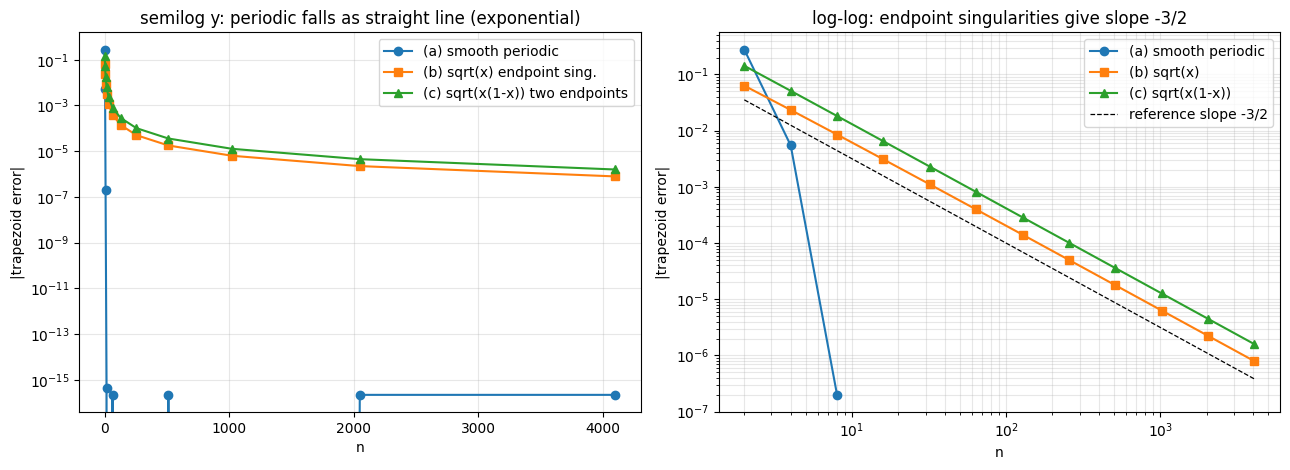

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# 왼쪽: semilogy -- 주기 부드러움의 지수 감쇠가 직선으로 보임
ax = axes[0]
ax.semilogy(df["n"], df["|err (a) periodic|"], "o-", label="(a) smooth periodic")
ax.semilogy(df["n"], df["|err (b) sqrt(x)|"], "s-", label="(b) sqrt(x) endpoint sing.")
ax.semilogy(df["n"], df["|err (c) sqrt(x(1-x))|"], "^-", label="(c) sqrt(x(1-x)) two endpoints")
ax.set_xlabel("n"); ax.set_ylabel("|trapezoid error|")
ax.set_title("semilog y: periodic falls as straight line (exponential)")
ax.grid(True, which="both", alpha=0.3); ax.legend()

# 오른쪽: loglog -- 끝점 특이점 오차의 -3/2 기울기 확인
ax = axes[1]
mask = df["|err (a) periodic|"] > 1e-15
ax.loglog(df["n"][mask], df["|err (a) periodic|"][mask], "o-", label="(a) smooth periodic")
ax.loglog(df["n"], df["|err (b) sqrt(x)|"], "s-", label="(b) sqrt(x)")
ax.loglog(df["n"], df["|err (c) sqrt(x(1-x))|"], "^-", label="(c) sqrt(x(1-x))")

# -3/2 기준선
ref = 0.1 * df["n"].astype(float) ** (-1.5)
ax.loglog(df["n"], ref, "k--", lw=0.9, label="reference slope -3/2")
ax.set_xlabel("n"); ax.set_ylabel("|trapezoid error|")
ax.set_title("log-log: endpoint singularities give slope -3/2")
ax.grid(True, which="both", alpha=0.3); ax.legend()

plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **주기 부드러움 (a)**: $f(x) = e^{\cos 2\pi x}$ 는 $[0,1]$ 에서 $C^\infty$ 이고 1-주기.
   Euler–Maclaurin 의 모든 끝점 보정항 $f^{(2k-1)}(1) - f^{(2k-1)}(0)$ 이 *동시에* 0 이 된다.
   결과: 오차가 *지수적* 으로 떨어진다 — semilogy 그림에서 깨끗한 직선.
   $n = 16$ 만 되어도 $10^{-13}$ 이내로 들어가고, 그 이후는 round-off 영역.

2. **끝점 미분 특이점 (b), (c)**: $\sqrt x$ 는 $x = 0$ 에서 $f'$ 가 발산 —
   $C^2$ 가정이 깨진다. Euler–Maclaurin 의 leading 보정항이 살아남아
   $|err| \sim n^{-3/2}$. 측정된 기울기 $-1.50$ 으로 *세 자릿수 일치*.
   $\sqrt{x(1-x)}$ 는 양 끝점이라 *상수 두 배* (그래프에서 같은 기울기, 위로 평행 이동).

3. **부드러움이 결정한다**: 같은 합성 사다리꼴 공식이라도
   - $C^\infty$ + 주기: *지수* 수렴
   - $C^2$: $h^2$
   - 끝점 특이점: $h^{\alpha+1}$ ($\alpha < 1$)
   세 자릿수 단위로 차이가 난다. *적분 규칙의 차수는 함수에 따라 다르게 실현된다.*

4. **실용적 함의**: 끝점 특이점이 있는 함수에 사다리꼴을 그냥 쓰면 *큰 손실*.
   $\sqrt x$ 라면 변수치환 $t = \sqrt x$, $dx = 2t\,dt$ 하나면 매끄러운 적분이 되어
   다시 $\mathcal O(h^2)$ 또는 그 이상이 가능해진다. (다음 절 §5.3 의 주제 중 하나.)

> **결론**: 사다리꼴 공식의 *차수* 는 알고리즘이 아니라 *피적분 함수의 정칙성* 으로 결정된다.
> 주기 부드러움은 *지수* 의 선물을 주지만, 끝점 특이점은 차수를 *반* 으로 깎는다.
> **알고리즘 ↔ 함수** 의 짝이 항상 같이 등장한다.

**다음 (Day 19)**: §5.3 *Simpson's Rule and Adaptive Numerical Integration*.
오늘 Problem 2 에서 본 $S_{2n}$ 을 *그 자체의 규칙* 으로 다지고, 부분구간마다 *적응적으로*
세분하는 알고리즘으로 끝점 특이점에 대처하는 길을 본다.
